In [3]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from skl2onnx.common.data_types import FloatTensorType
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_curve, roc_auc_score, auc, average_precision_score
from sklearn.model_selection import train_test_split
from typing import Iterable, Tuple
import math
import pickle
import skl2onnx

srcs = ['cf_a', 'cf_b', 'cf_c', 'cf_d', 'cf_e', 'cf_f', 'cf_g',
        'fb_a', 'fb_b', 'fb_c',
        'wm_t', 'wm_u']

import matplotlib.pylab as pylab
params = {
    'legend.fontsize': 'large',
    'figure.figsize': (6, 4),
    'axes.labelsize': 'large',
    'axes.titlesize':'large',
    'xtick.labelsize':'large',
    'ytick.labelsize':'large'
}
pylab.rcParams.update(params)

In [4]:
%cd analysis

/home/isaackhor/code/cfcache/analysis


In [17]:
def samplefn(x):
    return lambda i : random.random() > x

rename_tbl = pickle.load(open('rename_tbl.pkl', 'rb'))
cols = ['ts', 'next_ts', 'ttl', 'create_ts', 'freq', 'last_ts', 'update_ts', 'revals', 'good_rv', 'bad_rv', 'mime', 'size']
dfs = []
for c in ['a', 'b', 'c', 'd', 'e', 'f', 'g']:
    fn = f'cf_{c}'
    print(f'Loading {fn}...')
    sdf = pd.read_csv(f'../traces/expiry/r10{fn}.csv.zst', names=cols, skiprows=samplefn(0.03))
    sdf['in'] = fn
    sdf['src'] = rename_tbl.get(fn, fn)
    dfs.append(sdf)

for c in ['a', 'b', 'c']:
    print(f'Loading fb_{c}...')
    sdf = pd.read_csv(f'../traces/expiry/r10fb_{c}.csv.zst', names=cols, skiprows=samplefn(0.1))
    sdf['in'] = 'fb_' + c
    sdf['src'] = rename_tbl.get('fb_' + c, 'fb_' + c)
    dfs.append(sdf)

for c in ['t', 'u']:
    print(f'Loading wm_{c}...')
    sdf = pd.read_csv(f'../traces/expiry/r10wm_{c}.csv.zst', names=cols, skiprows=samplefn(0.05))
    sdf['in'] = 'wm_' + c
    sdf['src'] = rename_tbl.get('wm_' + c, 'wm_' + c)
    dfs.append(sdf)

df = pd.concat(dfs)
dfs = None
df

Loading cf_a...
Loading cf_b...
Loading cf_c...
Loading cf_d...
Loading cf_e...
Loading cf_f...
Loading cf_g...
Loading fb_a...
Loading fb_b...
Loading fb_c...
Loading wm_t...
Loading wm_u...


,ts,next_ts,ttl,create_ts,freq,last_ts,update_ts,revals,good_rv,bad_rv,mime,size,in,src
0,26,0,6,19,1,19,19,0,0,0,6,605,cf_a,BOS 1
1,29,29,2,26,13,27,26,0,0,0,6,596,cf_a,BOS 1
2,35,0,6,28,1,28,28,0,0,0,6,609,cf_a,BOS 1
3,36,2205,6,29,9,29,29,0,0,0,6,598,cf_a,BOS 1
4,39,0,6,32,1,32,32,0,0,0,6,598,cf_a,BOS 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
972849,1210031,1210186,86400,417,41,1207161,1123630,10385097,10472130,0,0,16892,wm_u,WM 2
972850,1210031,1210910,86400,417,149,1209839,1123630,10385105,10472130,0,0,5757,wm_u,WM 2
972851,1210031,1210902,86400,417,36,1209998,1123630,10385106,10472130,0,0,3278,wm_u,WM 2
972852,1210032,1212220,86400,418,77,1207568,1123631,10385162,10472161,0,0,1764,wm_u,WM 2


In [5]:
def calc_features(df: pd.DataFrame) -> pd.DataFrame:
    df['should_reval'] = (df['ts'] <= df['next_ts']) & (df['next_ts'] <= (df['ts'] + df['ttl'])) & (df['ttl'] < 7 * 86400)
    df['generations'] = ((df['ts'] - df['create_ts'] - 1) / df['ttl']).round()
    df['t_since_last'] = df['ts'] - df['last_ts']
    df['t_since_last_frac'] = (df['t_since_last'] - 1) / df['ttl']
    return df


def split_xy(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.Series]:
    y = df['should_reval']
    x = df[['ttl', 'freq', 'generations', 't_since_last', 't_since_last_frac', 'mime', 'size']]
    return x, y


def make_rfc(x_train, y_train, x_test, y_test) -> RandomForestClassifier:
    rfc = RandomForestClassifier(
        n_estimators=32,
        criterion='gini',
        min_samples_leaf=1 / 2000,
        random_state=42,
        n_jobs=-1,
    )
    rfc.fit(x_train, y_train)
    y_pred = rfc.predict(x_test)
    print(f'Train acc: {accuracy_score(y_train, rfc.predict(x_train)):0.4f}')
    print(f'Test acc: {accuracy_score(y_test, y_pred):0.4f}')
    print(classification_report(y_test, y_pred))
    return rfc

def train_model(sdf):
    x, y = split_xy(sdf)
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.33, random_state=42)
    x_train_over, y_train_over = RandomOverSampler(random_state=42).fit_resample(x_train, y_train) # type: ignore
    rfc = make_rfc(x_train_over, y_train_over, x_test, y_test)
    return rfc


df = calc_features(df)
df

,ts,next_ts,ttl,create_ts,freq,last_ts,update_ts,revals,good_rv,bad_rv,mime,size,in,src,should_reval,generations,t_since_last,t_since_last_frac
0,15,0,6,8,1,8,8,0,0,0,6,602,cf_a,BOS 1,False,1.0,7,1.000000
1,16,0,10,5,1,5,5,0,0,0,23,849,cf_a,BOS 1,False,1.0,11,1.000000
2,28,29,12,2,9,25,15,0,0,0,3,52023,cf_a,BOS 1,True,2.0,3,0.166667
3,30,257704,6,23,1,23,23,0,0,0,6,602,cf_a,BOS 1,False,1.0,7,1.000000
4,36,0,6,29,1,29,29,0,0,0,6,614,cf_a,BOS 1,False,1.0,7,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
974117,1210031,1210557,86400,417,68,1208574,1123630,10385062,10472130,0,0,8510,wm_u,WM 2,True,14.0,1457,0.016852
974118,1210031,1212546,86400,417,10,1205966,1123630,10385102,10472130,0,0,163181,wm_u,WM 2,True,14.0,4065,0.047037
974119,1210032,1214331,86400,418,3,1197728,1123631,10385125,10472161,0,0,5839,wm_u,WM 2,True,14.0,12304,0.142396
974120,1210032,1210129,86400,418,43,1206665,1123631,10385135,10472161,0,0,646,wm_u,WM 2,True,14.0,3367,0.038958


In [14]:
models = {}

for src in srcs:
    print(f'Training model for {src}...')
    sdf = df[df['in'] == src]
    rfc = train_model(sdf)
    models[src] = rfc

Training model for cf_a...
Train acc: 0.8395
Test acc: 0.8379
              precision    recall  f1-score   support

       False       0.94      0.84      0.89    149831
        True       0.62      0.84      0.71     47824

    accuracy                           0.84    197655
   macro avg       0.78      0.84      0.80    197655
weighted avg       0.86      0.84      0.85    197655

Training model for cf_b...
Train acc: 0.8340
Test acc: 0.8325
              precision    recall  f1-score   support

       False       0.94      0.83      0.88    194554
        True       0.62      0.83      0.71     63817

    accuracy                           0.83    258371
   macro avg       0.78      0.83      0.80    258371
weighted avg       0.86      0.83      0.84    258371

Training model for cf_c...
Train acc: 0.8422
Test acc: 0.8560
              precision    recall  f1-score   support

       False       0.96      0.86      0.91    281248
        True       0.57      0.82      0.67     611

In [15]:
acc_results = []
for train_src in srcs:
    row = {'train_src': train_src}
    model = models[train_src]
    for test_src in srcs:
        # print(f'Evaluating {train_src} model on {test_src} data...')
        test_df = df[df['in'] == test_src]
        x_test, y_test = split_xy(test_df)
        y_cf = model.predict(x_test)
        acc = accuracy_score(y_test, y_cf)
        row[test_src] = acc # type: ignore
    acc_results.append(row)

auc_roc_results = []
for train_src in srcs:
    row = {'train_src': train_src}
    model = models[train_src]
    for test_src in srcs:
        # print(f'Evaluating {train_src} model on {test_src} data...')
        test_df = df[df['in'] == test_src]
        x_test, y_test = split_xy(test_df)
        y_cf = model.predict(x_test)
        auc_roc = roc_auc_score(y_test, y_cf)
        row[test_src] = auc_roc # type: ignore
    auc_roc_results.append(row)

auc_prc_results = []
for train_src in srcs:
    row = {'train_src': train_src}
    model = models[train_src]
    for test_src in srcs:
        # print(f'Evaluating {train_src} model on {test_src} data...')
        test_df = df[df['in'] == test_src]
        x_test, y_test = split_xy(test_df)
        y_cf = model.predict(x_test)
        auc_prc = average_precision_score(y_test, y_cf)
        row[test_src] = auc_prc # type: ignore
    auc_prc_results.append(row)


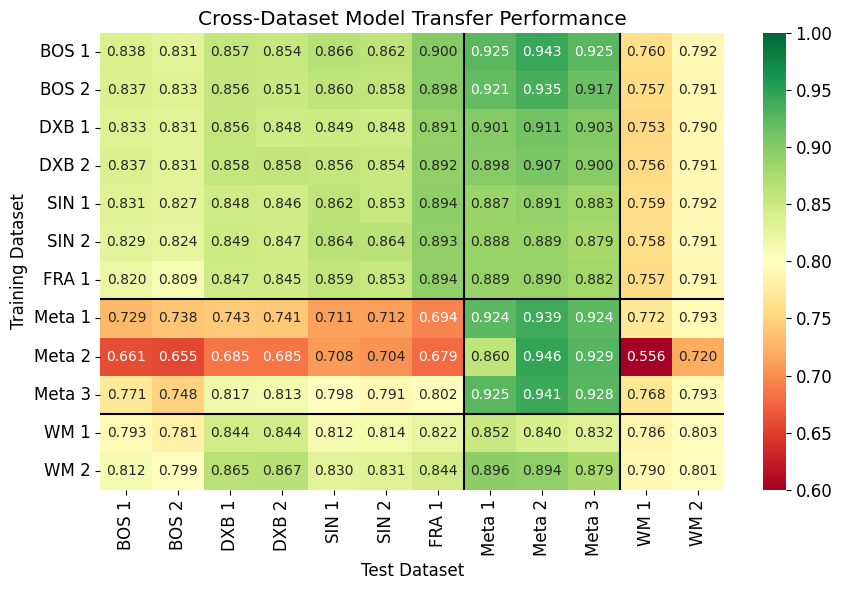

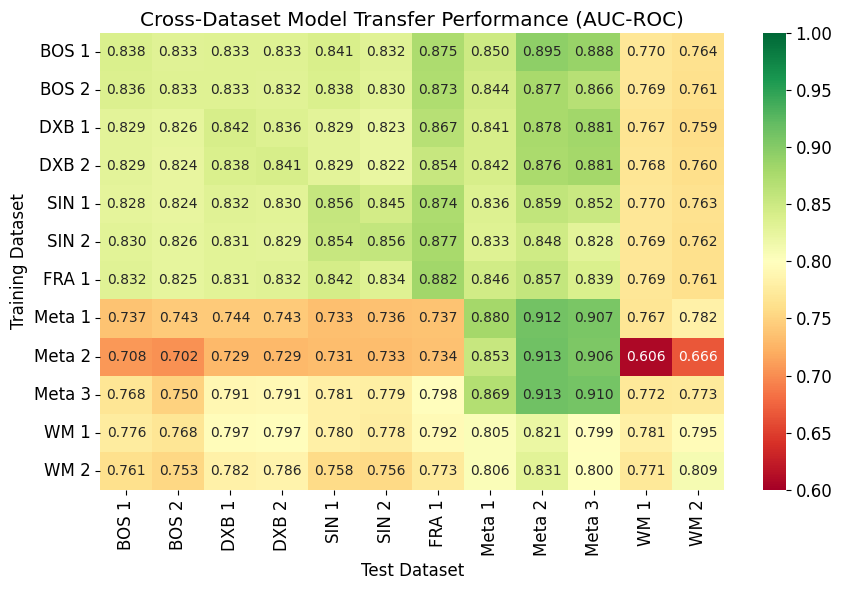

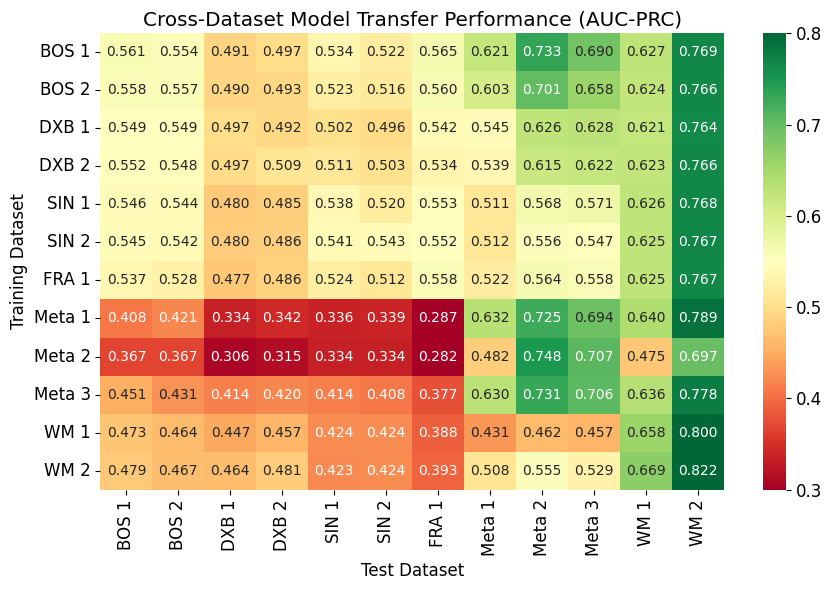

In [16]:
hm_min = 0.6

ticks = sorted(list(srcs))
tick_lbls = [rename_tbl.get(t, t) for t in ticks]

accuracy_matrix = pd.DataFrame(acc_results)
accuracy_matrix = accuracy_matrix.set_index('train_src')
plt.figure(figsize=(9, 6))
sns.heatmap(accuracy_matrix, annot=True, fmt='.3f', cmap='RdYlGn', 
            vmin=hm_min, vmax=1.0)
plt.title('Cross-Dataset Model Transfer Performance', fontsize='x-large')
plt.xticks(ticks=np.arange(len(ticks)) + 0.5, labels=tick_lbls)
plt.yticks(ticks=np.arange(len(ticks)) + 0.5, labels=tick_lbls)
plt.axvline(x=7, color='black', linestyle='-')
plt.axvline(x=10, color='black', linestyle='-')
plt.axhline(y=7, color='black', linestyle='-')
plt.axhline(y=10, color='black', linestyle='-')
plt.xlabel('Test Dataset')
plt.ylabel('Training Dataset')
plt.tight_layout()
plt.savefig('../paper/figs/cross_dataset_accuracy_heatmap.png')
plt.show()

auc_matrix = pd.DataFrame(auc_roc_results)
auc_matrix = auc_matrix.set_index('train_src')
plt.figure(figsize=(9, 6))
sns.heatmap(auc_matrix, annot=True, fmt='.3f', cmap='RdYlGn', 
            vmin=hm_min, vmax=1.0)
plt.title('Cross-Dataset Model Transfer Performance (AUC-ROC)', fontsize='x-large')
plt.xlabel('Test Dataset')
plt.xticks(ticks=np.arange(len(ticks)) + 0.5, labels=tick_lbls)
plt.yticks(ticks=np.arange(len(ticks)) + 0.5, labels=tick_lbls)
plt.ylabel('Training Dataset')
plt.tight_layout()
plt.savefig('../paper/figs/cross_dataset_auc_roc_heatmap.png')
plt.show()

auc_matrix = pd.DataFrame(auc_prc_results)
auc_matrix = auc_matrix.set_index('train_src')
plt.figure(figsize=(9, 6))
sns.heatmap(auc_matrix, annot=True, fmt='.3f', cmap='RdYlGn', 
            vmin=0.3, vmax=0.8)
plt.title('Cross-Dataset Model Transfer Performance (AUC-PRC)', fontsize='x-large')
plt.xlabel('Test Dataset')
plt.ylabel('Training Dataset')
plt.xticks(ticks=np.arange(len(ticks)) + 0.5, labels=tick_lbls)
plt.yticks(ticks=np.arange(len(ticks)) + 0.5, labels=tick_lbls)
plt.tight_layout()
plt.savefig('../paper/figs/cross_dataset_auc_prc_heatmap.png')
plt.show()

# regular model stats

In [9]:
df_cfall = df[df['in'].str.startswith('cf_')]
df_fball = df[df['in'].str.startswith('fb_')]
df_wmall = df[df['in'].str.startswith('wm_')]

# cf_model = train_model(df_cfall)
# fb_model = train_model(df_fball)
# wm_model = train_model(df_wmall)

# read from dump
with open('../models/v10_cf_rfc.pkl', 'rb') as f:
    cf_model = pickle.load(f)
with open('../models/v10_fb_rfc.pkl', 'rb') as f:
    fb_model = pickle.load(f)
with open('../models/v10_wm_rfc.pkl', 'rb') as f:
    wm_model = pickle.load(f)

In [10]:
def collect_model_stats(sdf, model):
    """Collect statistics without plotting"""
    x, y = split_xy(sdf)
    _, x_test, _, y_test = train_test_split(
        x, y, test_size=0.33, random_state=42)
    
    # ROC curve
    y_pred_proba = model.predict_proba(x_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # PRC curve
    from sklearn.metrics import precision_recall_curve
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    prc_auc = average_precision_score(y_test, y_pred_proba)
    
    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': x.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    return {
        'fpr': fpr,
        'tpr': tpr,
        'roc_auc': roc_auc,
        'precision': precision,
        'recall': recall,
        'prc_auc': prc_auc,
        'feature_importance': feature_importance
    }

# Collect stats for all models
cf_stats = collect_model_stats(df_cfall, cf_model)
fb_stats = collect_model_stats(df_fball, fb_model)
wm_stats = collect_model_stats(df_wmall, wm_model)

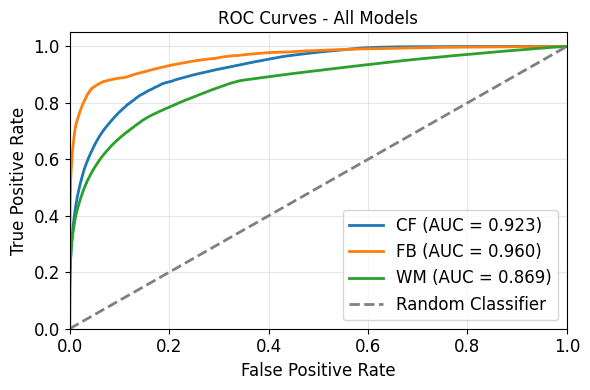

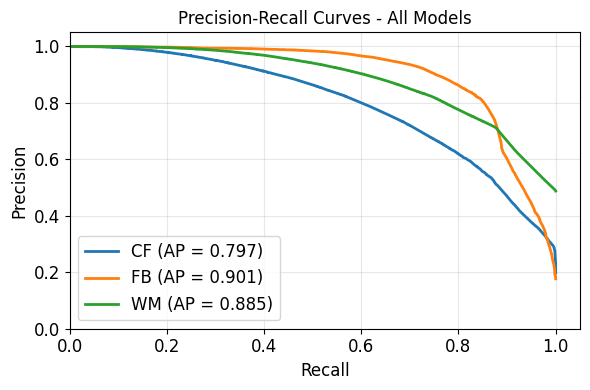

In [11]:
# Plot ROC curves for all models
plt.figure()
plt.plot(cf_stats['fpr'], cf_stats['tpr'], lw=2, 
         label=f"CF (AUC = {cf_stats['roc_auc']:.3f})")
plt.plot(fb_stats['fpr'], fb_stats['tpr'], lw=2, 
         label=f"FB (AUC = {fb_stats['roc_auc']:.3f})")
plt.plot(wm_stats['fpr'], wm_stats['tpr'], lw=2, 
         label=f"WM (AUC = {wm_stats['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../paper/figs/all_models_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot PRC curves for all models
plt.figure()
plt.plot(cf_stats['recall'], cf_stats['precision'], lw=2, 
         label=f"CF (AP = {cf_stats['prc_auc']:.3f})")
plt.plot(fb_stats['recall'], fb_stats['precision'], lw=2, 
         label=f"FB (AP = {fb_stats['prc_auc']:.3f})")
plt.plot(wm_stats['recall'], wm_stats['precision'], lw=2, 
         label=f"WM (AP = {wm_stats['prc_auc']:.3f})")
plt.xlim([0.0, 1.05])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves - All Models')
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../paper/figs/all_models_prc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

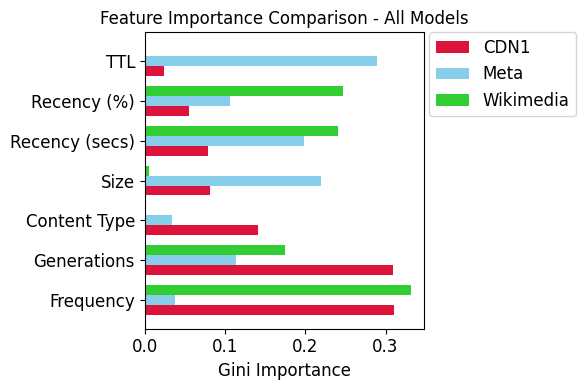

In [12]:
# Plot feature importances for all models as grouped bar chart
features = sorted(cf_stats['feature_importance']['feature'].tolist())
cf_importances = cf_stats['feature_importance']['importance'].tolist()
fb_importances = fb_stats['feature_importance'].set_index('feature').loc[features, 'importance'].tolist()
wm_importances = wm_stats['feature_importance'].set_index('feature').loc[features, 'importance'].tolist()

y = np.arange(len(features))
h = 0.25

fig, ax = plt.subplots()
ax.barh(y - h, cf_importances, height=h, label='CDN1', color='crimson')
ax.barh(y, fb_importances, height=h, label='Meta', color='skyblue')
ax.barh(y + h, wm_importances, height=h, label='Wikimedia', color='limegreen')

feature_rename = {
    'ttl': 'TTL',
    'freq': 'Frequency',
    'generations': 'Generations',
    't_since_last': 'Recency (secs)',
    't_since_last_frac': 'Recency (%)',
    'mime': 'Content Type',
    'size': 'Size',
}

ax.set_yticks(y, [feature_rename.get(f, f) for f in features])
ax.set_xlabel('Gini Importance')
ax.set_title('Feature Importance Comparison - All Models')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.savefig('../paper/figs/all_models_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# try out random heuristic models

In [20]:
def get_heuristic_model(min_ttl=1, min_freq=1, max_t_since_last_frac=1.0):
    return lambda d:  ((d['ttl'] <= min_ttl) & (d['freq'] <= min_freq) & (d['t_since_last_frac'] <= max_t_since_last_frac))

ttls = [0, 5, 10, 30, 60, 900, 3600, 21600, 86400, 7*86400, 14*86400, 30*86400]
freqs = list(range(0, 7))
t_since_last_fracs = list(np.linspace(0.0, 1.0, num=20))
# gens = list(range(0, 10))

import itertools
heuristics = [get_heuristic_model(*h) for h in itertools.product(ttls, freqs, t_since_last_fracs)]
print(f'Generated {len(heuristics)} heuristics.')

Generated 1680 heuristics.


In [ ]:
def get_heuristic_model(min_ttl=1, min_freq=1, max_t_since_last_frac=1.0, always_reval_gen=999):
    return lambda d: (d['generations'] >= always_reval_gen) | ((d['ttl'] <= min_ttl) & (d['freq'] <= min_freq) & (d['t_since_last_frac'] <= max_t_since_last_frac))

ttls = [0, 5, 10, 30, 60, 900, 3600, 21600, 86400, 7*86400, 14*86400, 30*86400]
freqs = list(range(0, 7))
t_since_last_fracs = list(np.linspace(0.0, 1.0, num=20))
gens = list(range(0, 10))

import itertools
heuristics = [get_heuristic_model(*h) for h in itertools.product(ttls, freqs, t_since_last_fracs, gens)]
print(f'Generated {len(heuristics)} heuristics.')

Generated 1680 heuristics.


In [21]:
from sklearn.metrics import precision_score, recall_score

# test on cf

xall_cf, yall_cf = split_xy(df_cfall.sample(frac=0.05, random_state=42))
xall_fb, yall_fb = split_xy(df_fball.sample(frac=0.05, random_state=42))
xall_wm, yall_wm = split_xy(df_wmall.sample(frac=0.05, random_state=42))
prevalence = yall_cf.sum() / len(yall_cf)
display(xall_cf, xall_fb, xall_wm)

# Evaluate each heuristic
results = []
for i, heuristic in enumerate(heuristics):
    if i % 10 == 0 and i > 0:
        print('.', end='', flush=True)
    if i % 1000 == 0 and i > 0:
        print()

    y_cf = heuristic(xall_cf)
    if y_cf.sum() > 0:
        precision = precision_score(yall_cf, y_cf, zero_division=0)
        recall = recall_score(yall_cf, y_cf, zero_division=0)
        results.append({
            'heuristic_id': i,
            'precision': precision,
            'recall': recall,
            'src': 'CDN1',
        })

    y_fb = heuristic(xall_fb)
    if y_fb.sum() > 0:
        precision = precision_score(yall_fb, y_fb, zero_division=0)
        recall = recall_score(yall_fb, y_fb, zero_division=0)
        results.append({
            'heuristic_id': i,
            'precision': precision,
            'recall': recall,
            'src': 'Meta',
        })

    y_wm = heuristic(xall_wm)
    if y_wm.sum() > 0:
        precision = precision_score(yall_wm, y_wm, zero_division=0)
        recall = recall_score(yall_wm, y_wm, zero_division=0)
        results.append({
            'heuristic_id': i,
            'precision': precision,
            'recall': recall,
            'src': 'Wiki',
        })

heuristic_df = pd.DataFrame(results)
print('\ndone')

,ttl,freq,generations,t_since_last,t_since_last_frac,mime,size
310986,30,1,1.0,31,1.000000,29,132924
518800,1,1,3.0,2,1.000000,6,341
228304,14400,1,1.0,14401,1.000000,3,1386
452125,86400,1392,13.0,46,0.000521,25,351
485761,14400,1,2.0,1732,0.120208,5,1041871
...,...,...,...,...,...,...,...
235634,30,1,1.0,31,1.000000,19,9194
589836,30,1,1.0,31,1.000000,19,15874
820768,6,1,1.0,7,1.000000,6,609
91264,14400,1,1.0,14401,1.000000,16,85881


,ttl,freq,generations,t_since_last,t_since_last_frac,mime,size
40094,900,4,1.0,901,1.000000,28,368080
44398,900,2,1.0,901,1.000000,28,47527
29771,900,2,1.0,897,0.995556,28,50811
59531,900,1,1.0,901,1.000000,28,682519
264840,900,2,1.0,901,1.000000,28,279171
...,...,...,...,...,...,...,...
383422,129600,2,0.0,15635,0.120633,16,122943
582780,900,1,1.0,901,1.000000,28,35170
129420,900,3,1.0,899,0.997778,28,16571
519182,1,2,113.0,1,0.000000,28,1233


,ttl,freq,generations,t_since_last,t_since_last_frac,mime,size
518125,86400,1,1.0,86401,1.000000,0,26567
129937,86400,2,1.0,86401,1.000000,0,6627
1337610,86400,3,10.0,40736,0.471470,0,10748
515575,86400,1,1.0,86401,1.000000,0,9388
169943,86400,4,3.0,39537,0.457593,0,26342
...,...,...,...,...,...,...,...
392497,86400,3,1.0,37158,0.430058,0,17182
596291,86400,18,9.0,2227,0.025764,0,43798
164507,86400,45,3.0,85,0.000972,0,9709
339170,86400,1,1.0,86401,1.000000,0,12935


....................................................................................................
...................................................................
done


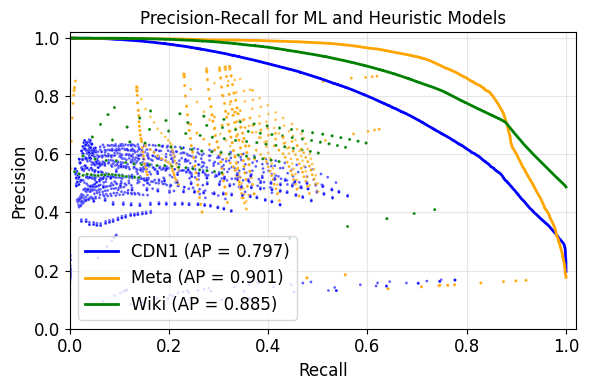

Total heuristics evaluated: 3239
Prevalence: 0.1971
Best precision: 1.0000
Best recall: 0.9193


In [30]:

# Plot precision-recall scatter with prevalence baseline
plt.figure(figsize=(6, 4))
sns.scatterplot(data=heuristic_df, x='recall', y='precision', hue='src', alpha=0.66, s=4, palette={'CDN1': 'blue', 'Meta': 'orange', 'Wiki': 'green'}, legend=False)
# plt.scatter(heuristic_df['recall'], heuristic_df['precision'], alpha=0.6, s=4)

# also include for reference ML models
plt.plot(cf_stats['recall'], cf_stats['precision'], lw=2, label=f"CDN1 (AP = {cf_stats['prc_auc']:.3f})", color='blue')
plt.plot(fb_stats['recall'], fb_stats['precision'], lw=2, label=f"Meta (AP = {fb_stats['prc_auc']:.3f})", color='orange')
plt.plot(wm_stats['recall'], wm_stats['precision'], lw=2, label=f"Wiki (AP = {wm_stats['prc_auc']:.3f})", color='green')

# Prevalence baseline line: at any recall, precision should be >= prevalence
# plt.plot([0, 1], [prevalence, prevalence], 'r--', lw=2, label=f'Prevalence = {prevalence:.3f}')

plt.xlim([0, 1.02])
plt.ylim([0, 1.02])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall for ML and Heuristic Models')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../paper/figs/heuristic_ml_prc_combined.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Total heuristics evaluated: {len(results)}")
print(f"Prevalence: {prevalence:.4f}")
print(f"Best precision: {heuristic_df['precision'].max():.4f}")
print(f"Best recall: {heuristic_df['recall'].max():.4f}")

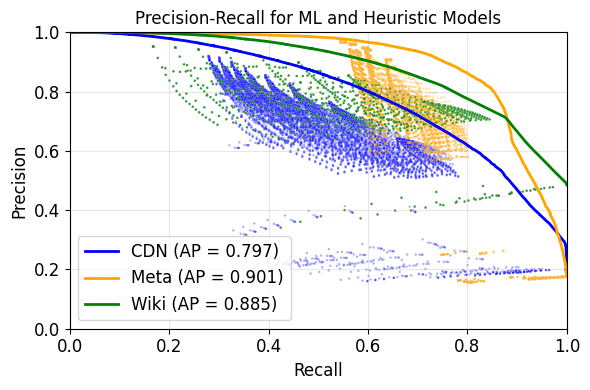

Total heuristics evaluated: 50400
Prevalence: 0.1971
Best precision: 0.9699
Best recall: 1.0000


In [ ]:

# Plot precision-recall scatter with prevalence baseline
plt.figure(figsize=(6, 4))
# sns.scatterplot(data=heuristic_df, x='recall', y='precision', hue='src', alpha=0.6, s=4, palette={'CDN1': 'crimson', 'Meta': 'skyblue', 'Wiki': 'limegreen'})
sns.scatterplot(data=heuristic_df, x='recall', y='precision', hue='src', alpha=0.33, s=3, palette={'CDN1': 'blue', 'Meta': 'orange', 'Wiki': 'green'}, legend=False)
# plt.scatter(heuristic_df['recall'], heuristic_df['precision'], alpha=0.6, s=4)

# also include for reference ML models
plt.plot(cf_stats['recall'], cf_stats['precision'], lw=2, label=f"CDN (AP = {cf_stats['prc_auc']:.3f})", color='blue')
plt.plot(fb_stats['recall'], fb_stats['precision'], lw=2, label=f"Meta (AP = {fb_stats['prc_auc']:.3f})", color='orange')
plt.plot(wm_stats['recall'], wm_stats['precision'], lw=2, label=f"Wiki (AP = {wm_stats['prc_auc']:.3f})", color='green')

# Prevalence baseline line: at any recall, precision should be >= prevalence
# plt.plot([0, 1], [prevalence, prevalence], 'r--', lw=2, label=f'Prevalence = {prevalence:.3f}')

plt.xlim([0, 1])
plt.ylim([0, 1])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall for ML and Heuristic Models')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('../paper/figs/heuristic_ml_prc_combined.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Total heuristics evaluated: {len(results)}")
print(f"Prevalence: {prevalence:.4f}")
print(f"Best precision: {heuristic_df['precision'].max():.4f}")
print(f"Best recall: {heuristic_df['recall'].max():.4f}")

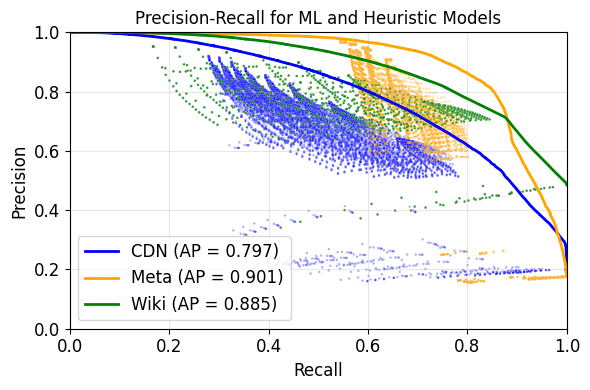

Total heuristics evaluated: 50400
Prevalence: 0.1971
Best precision: 0.9699
Best recall: 1.0000


In [ ]:

# Plot precision-recall scatter with prevalence baseline
plt.figure(figsize=(6, 4))
# sns.scatterplot(data=heuristic_df, x='recall', y='precision', hue='src', alpha=0.6, s=4, palette={'CDN1': 'crimson', 'Meta': 'skyblue', 'Wiki': 'limegreen'})
sns.scatterplot(data=heuristic_df, x='recall', y='precision', hue='src', alpha=0.33, s=3, palette={'CDN1': 'blue', 'Meta': 'orange', 'Wiki': 'green'}, legend=False)
# plt.scatter(heuristic_df['recall'], heuristic_df['precision'], alpha=0.6, s=4)

# also include for reference ML models
plt.plot(cf_stats['recall'], cf_stats['precision'], lw=2, label=f"CDN (AP = {cf_stats['prc_auc']:.3f})", color='blue')
plt.plot(fb_stats['recall'], fb_stats['precision'], lw=2, label=f"Meta (AP = {fb_stats['prc_auc']:.3f})", color='orange')
plt.plot(wm_stats['recall'], wm_stats['precision'], lw=2, label=f"Wiki (AP = {wm_stats['prc_auc']:.3f})", color='green')

# Prevalence baseline line: at any recall, precision should be >= prevalence
# plt.plot([0, 1], [prevalence, prevalence], 'r--', lw=2, label=f'Prevalence = {prevalence:.3f}')

plt.xlim([0, 1])
plt.ylim([0, 1])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall for ML and Heuristic Models')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('../paper/figs/heuristic_ml_prc_combined.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Total heuristics evaluated: {len(results)}")
print(f"Prevalence: {prevalence:.4f}")
print(f"Best precision: {heuristic_df['precision'].max():.4f}")
print(f"Best recall: {heuristic_df['recall'].max():.4f}")